In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

### Combined training

Same neighbor -> IF prediction pipeline as `sender_predict.ipynb`, but trained across
MULTIPLE images at once to expand the training set, instead of a single image's cells.

Cells in different images/wells are never spatially adjacent, so `models.gnn.
build_multi_image_prediction_data` builds an INDEPENDENT radius graph per image and
concatenates them into one combined graph -- message passing never crosses between
images, only the train/val/test split and the fitted scalers are shared across all of
them. `local_density`/border exclusion are still computed per-image beforehand (each
image has its own neighborhoods/edges), same as any single-image run.

Images must share the same marker panel (`channel_names`) to be combined.

In [2]:
IMG_NAMES = [
    '20260717T120225_pA_Activin_D4_48hr_W0001',
    '20260717T120225_pA_Activin_D4_48hr_W0003',
    # '20260717T120225_pA_Activin_D4_48hr_W0027',
]
channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
if_cols = [c + '_mean' for c in channel_names if c != 'Hoechst']

COMBINED_TAG = '+'.join(name.split('_')[-1] for name in IMG_NAMES)  # e.g. 'W0001+W0013' -- used for fig/checkpoint naming
PREFIX = IMG_NAMES[0].rsplit('_', 1)[0]
print('Combining:', IMG_NAMES)
print('COMBINED_TAG:', COMBINED_TAG)
print('IMG_NAME', PREFIX)

Combining: ['20260717T120225_pA_Activin_D4_48hr_W0001', '20260717T120225_pA_Activin_D4_48hr_W0003']
COMBINED_TAG: W0001+W0003
IMG_NAME 20260717T120225_pA_Activin_D4_48hr


In [3]:
cell_dfs = []
image_shapes = []
for img_name in IMG_NAMES:
    df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
    out = tiff.imread(f'../data/stitched/{img_name}.tif')
    cell_dfs.append(df)
    image_shapes.append(out.shape[1:])
    print(f'{img_name}: {df.shape[0]} cells, image shape {out.shape[1:]}')

fig_dir = f'../results/figures/combined/{PREFIX}_{COMBINED_TAG}'
os.makedirs(fig_dir, exist_ok=True)

20260717T120225_pA_Activin_D4_48hr_W0001: 8794 cells, image shape (1998, 1998)
20260717T120225_pA_Activin_D4_48hr_W0003: 9302 cells, image shape (1998, 1998)


### Prediction

In [4]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_loss_curves, local_density
from models.gnn import (
    build_multi_image_prediction_data, train_neighbor_predictor, NeighborIFPredictor,
    predict_df as gnn_predict_df, border_mask, save_model,
)
from models.gat import NeighborIFPredictorGAT

PRED_RADIUS = 200  # px -- create a graph (every pair within radius is connected), NOT k-NN
DENSITY_RADIUS = 50  # compute number of cells within this radius as a feature
GLOBAL_X_COLS = ['Activin_mean', 'local_density']
NEIGHBOR_X_COLS = ['Activin_mean', 'local_density']
YIF = 'FoxA2'
Y_COLS = [f'{YIF}_mean']
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler
SEED = 0

# local_density/border exclusion computed PER IMAGE -- each image has its own
# neighborhoods and its own edges, so these can't be computed on the concatenated data.
border_radius = max(PRED_RADIUS, DENSITY_RADIUS)
is_border_parts = []
for df, image_shape in zip(cell_dfs, image_shapes):
    centroids = df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
    df['local_density'] = local_density(centroids, radius=DENSITY_RADIUS)
    is_border_parts.append(border_mask(centroids, image_shape, border_radius))

N_per_image = [len(df) for df in cell_dfs]
N = sum(N_per_image)
is_border = np.concatenate(is_border_parts)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {border_radius}px of a border -- excluded as targets')

# One split over the COMBINED valid cells -- train/val/test each end up with a mix of
# cells from every image, same random-subset convention as split_indices' single-image use.
train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

# MultiIndex (image_name, cell_id) -- plain cell_id collides across images (each image's
# cell_df is independently 1..N indexed), so predict_df needs a de-duplicated index.
combined_index = pd.concat(
    [pd.Series(1, index=df.index) for df in cell_dfs], keys=IMG_NAMES
).index

pred_data = build_multi_image_prediction_data(
    cell_dfs, image_shapes, if_cols, radius=PRED_RADIUS,
    global_x_cols=GLOBAL_X_COLS, neighbor_x_cols=NEIGHBOR_X_COLS, y_cols=Y_COLS,
    train_idx=train_idx, scaling=SCALING,
    # local_density has neither a real "background" floor nor a right-skewed tail the
    # way an intensity channel does -- see models.gnn.ColumnScaler.
    no_background_cols=['local_density'],
    no_transform_cols=['local_density'],
)
print('neighbor_x_cols (seen only via neighbors):', pred_data['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', pred_data['global_x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells ({N_per_image} per image), {pred_data['edge_index'].shape[1]} directed edges (radius={PRED_RADIUS}px)")

6788 / 18096 cells within 200px of a border -- excluded as targets
neighbor_x_cols (seen only via neighbors): ['Activin_mean', 'local_density']
global_x_cols (seen directly, incl. self): ['Activin_mean', 'local_density']
y_cols (predicted): ['FoxA2_mean']
18096 cells ([8794, 9302] per image), 4652618 directed edges (radius=200px)


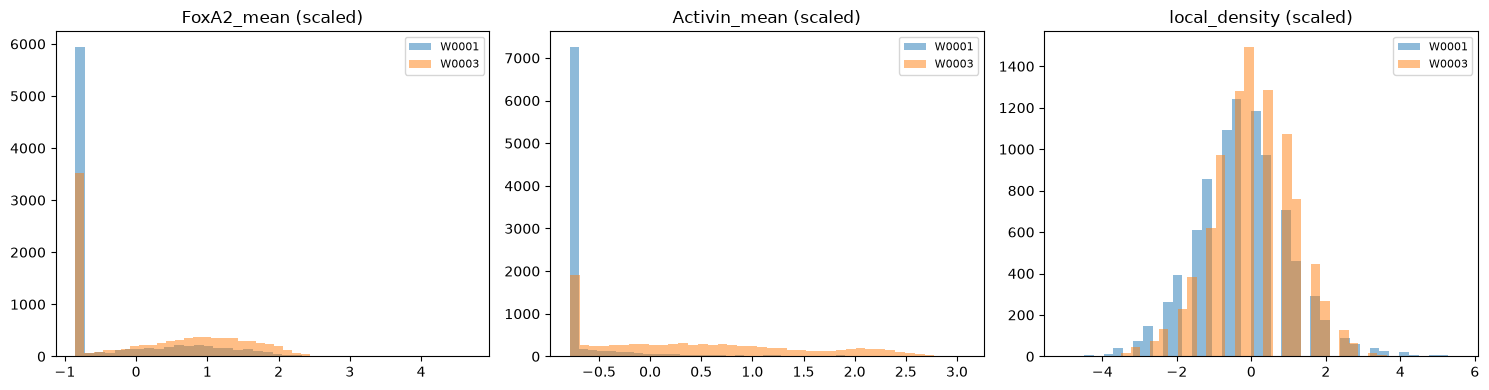

In [5]:
# Check the dynamic range per image, not just combined -- a scaler fit across images
# assumes they're on a comparable scale to begin with. If one image's cloud sits
# systematically off from the other's here, the shared scaler is compromising on both
# rather than fitting either well, and it's worth reconsidering whether these two
# images belong in the same training run at all.
image_labels = np.concatenate([[name] * n for name, n in zip(IMG_NAMES, N_per_image)])

data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
for i, col in enumerate(pred_data['global_x_cols']):
    data[col] = pred_data['x_global'][:, i]
data['image'] = image_labels

cols = pred_data['y_cols'] + pred_data['global_x_cols']
fig, axs = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))
axs = np.atleast_1d(axs)
for ax, col in zip(axs, cols):
    for name in IMG_NAMES:
        ax.hist(data.loc[data['image'] == name, col], bins=40, alpha=0.5, label=name.split('_')[-1])
    ax.set_title(f'{col} (scaled)')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(f'{fig_dir}/combined_range_check.png', dpi=300)
plt.show()

In [ ]:
GNN_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
)

torch.manual_seed(SEED)
gnn_model = NeighborIFPredictor(**GNN_KWARGS)
gnn_history = train_neighbor_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN',
    epochs=1500, lr=1e-3,
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title='Neighbor -> IF prediction (combined images, radius GNN)')
plt.show()

gnn_checkpoint_path = f'../results/models/combined_{COMBINED_TAG}_xActivin_y{YIF}_gnn.pt'
save_model(
    gnn_checkpoint_path, gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS,
)
print(f'Saved model to {gnn_checkpoint_path}')

GNN, test set, ORIGINAL units:


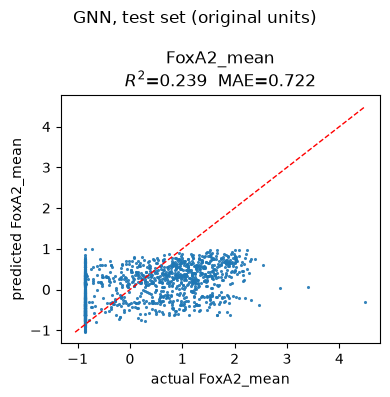

In [ ]:
# Both units shown explicitly -- R2 is NOT invariant under log1p_standard, so "scaled"
# and "original" can look very different for the same model (see gnn_predict_df's
# y_scaler param). Default call = original units; y_scaler=None = scaled units.
gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, combined_index, y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
print('GNN, test set, ORIGINAL units:')
fig_gnn_pred = plot_pred_vs_actual(gnn_true_test, gnn_pred_test, title='GNN, test set (original units)')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')


GAT:   0%|          | 0/1000 [00:00<?, ?it/s]

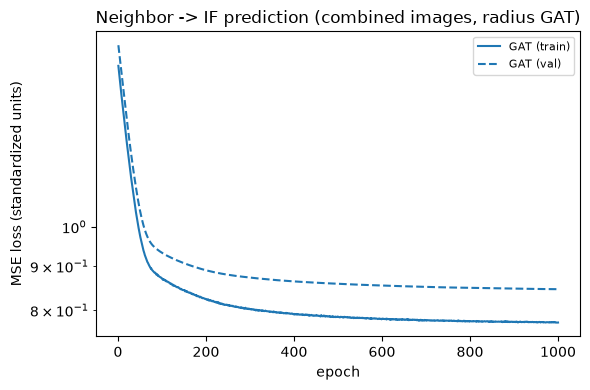

GAT, test set


,R2,MAE
feature,,
FoxA2_mean,0.242765,0.718043


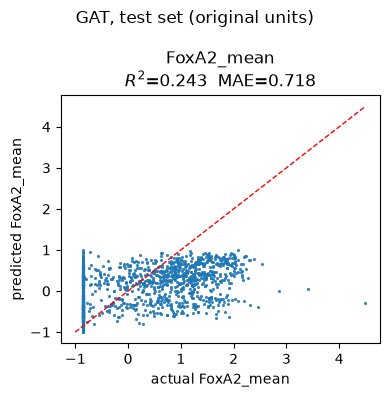

Saved model to ../results/models/combined_W0001+W0003_xActivin_yFoxA2_gat.pt


In [19]:
GAT_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
)

torch.manual_seed(SEED)
gat_model = NeighborIFPredictorGAT(**GAT_KWARGS)
gat_history = train_neighbor_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=1000, lr=1e-3,
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title='Neighbor -> IF prediction (combined images, radius GAT)')
plt.show()

gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, combined_index, y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
print('GAT, test set')
display(gat_r2)

fig_gat_pred = plot_pred_vs_actual(gat_true_test, gat_pred_test, title='GAT, test set (original units)')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

gat_checkpoint_path = f'../results/models/combined_{COMBINED_TAG}_xActivin_y{YIF}_gat.pt'
save_model(
    gat_checkpoint_path, gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS,
)
print(f'Saved model to {gat_checkpoint_path}')

In [20]:
comparison = pd.concat(
    {
        'GNN (fixed weights), original': gnn_r2,
        'GAT (learned attention), original': gat_r2,
    },
    axis=1,
)
display(comparison)

GNN (fixed weights), original             \
                                      R2        MAE   
feature                                               
FoxA2_mean                     -0.004969  26.146872   

           GAT (learned attention), original            
                                          R2       MAE  
feature                                                 
FoxA2_mean                          0.242765  0.718043

### Understanding the GAT: attention weights

Same interpretability checks as `sender_predict.ipynb`, applied to the combined-images
GAT -- attention is still computed edge-by-edge, and since no edge ever crosses between
images (see `build_multi_image_prediction_data`), distance/marker correlations here
reflect the same within-image neighbor relationships as a single-image run, just pooled
across more of them.

In [ ]:
centroids_combined = np.concatenate(
    [df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32) for df in cell_dfs], axis=0
)

edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.NeighborRadiusGAT.attention_by_layer) --
# with num_layers > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x_neighbor'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids_combined)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# neighbor_x_cols values; deeper layers' attention operates on the embeddings that
# resulted from earlier layers, so a correlation there reflects an indirect/aggregate
# relationship with the raw marker, not a direct one.
neighbor_cols = pred_data['neighbor_x_cols']
n_panels = 1 + len(neighbor_cols)
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px)')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(neighbor_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x_neighbor'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (neighbor, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and neighbor markers, by layer (combined images)', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell below (single-example-cell map) uses the FINAL layer's attention -- the one that
# most directly determines what reaches the prediction head.
att_weights = layer_attentions[-1]

In [ ]:
# One example (held-out test) cell -- since edges never cross images, its neighbors are
# guaranteed to be from the SAME image it belongs to. One attention-weight panel PER
# LAYER (positions are identical across layers -- only the coloring/attention values
# change, since each layer's attention is a genuinely different, separately-learned
# quantity, see the "distance and neighbor markers, by layer" cell above), then one
# panel per neighbor marker (these don't depend on layer at all, so shown once).
example_cell_pos = test_idx[0]
mask_edges = (dst == example_cell_pos)
neighbor_pos = src[mask_edges].numpy()

n_layers = len(layer_attentions)
n_panels = n_layers + len(neighbor_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    neighbor_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids_combined[neighbor_pos, 1], centroids_combined[neighbor_pos, 0], c=neighbor_att, cmap='viridis', s=100)
    ax.scatter(centroids_combined[example_cell_pos, 1], centroids_combined[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(neighbor_cols):
    ax = axes[n_layers + j]
    values = pred_data['x_neighbor'][neighbor_pos, j].numpy()
    sc = ax.scatter(centroids_combined[neighbor_pos, 1], centroids_combined[neighbor_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids_combined[example_cell_pos, 1], centroids_combined[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. neighbor markers: cell {combined_index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example.png', dpi=300, bbox_inches='tight')
plt.show()

### Cross-predict

Same idea as `cross_predict.ipynb`, applied to a checkpoint trained on the COMBINED
images above: loads a saved checkpoint and evaluates it against a cell table -- point
`EVAL_IMG_NAME` at any image with the same marker panel. Since this checkpoint was
already trained across multiple images, the most meaningful test is a THIRD image
that wasn't part of the combined training set at all (a real generalization check,
not just a mechanics check against one of its own training images).

Standalone/self-contained on purpose -- redefines its own config rather than reusing
`COMBINED_TAG`/`YIF` from the cells above, so this section can be run on its own after
a kernel restart without re-running the (slow) multi-image training.

In [51]:
TRAIN_TAG = 'W0001+W0003'  # the COMBINED_TAG used when this checkpoint was saved above
MODEL_TYPE = 'gat'  # 'gnn' | 'gat' -- must match how the checkpoint was saved
PREDICT_TYPE = '_xActivin_yFoxA2'  # should be '' or '_xX_yY' format, matching YIF used above

EVAL_IMG_NAME = '20260717T120225_pA_Activin_D4_48hr_W0002'  # cell table to evaluate against --
                                                              # ideally an image NOT in the combined training set

FIGURE_DIR = f'../results/figures/combined/{TRAIN_TAG}{PREDICT_TYPE}/cross_predict'
os.makedirs(FIGURE_DIR, exist_ok=True)

In [52]:
from models.gnn import load_model, apply_prediction_data, predict_df, border_mask, NeighborIFPredictor
from models.gat import NeighborIFPredictorGAT
from tools.morphology import r2_table, plot_pred_vs_actual, local_density

model_cls = NeighborIFPredictor if MODEL_TYPE == 'gnn' else NeighborIFPredictorGAT
checkpoint_path = f'../results/models/combined_{TRAIN_TAG}{PREDICT_TYPE}_{MODEL_TYPE}.pt'
model, checkpoint = load_model(checkpoint_path, model_cls)

print(f'Loaded {checkpoint_path}')
print('neighbor_x_cols (seen only via neighbors):', checkpoint['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', checkpoint['global_x_cols'])
print('y_cols (predicted):', checkpoint['y_cols'])
print('radius:', checkpoint['radius'])
print('density_radius:', checkpoint.get('density_radius'))

Loaded ../results/models/combined_W0001+W0003_xActivin_yFoxA2_gat.pt
neighbor_x_cols (seen only via neighbors): ['Activin_mean', 'local_density']
global_x_cols (seen directly, incl. self): ['Activin_mean', 'local_density']
y_cols (predicted): ['FoxA2_mean']
radius: 200
density_radius: 50


In [53]:
eval_cell_df = pd.read_parquet(f'../data/stitched/{EVAL_IMG_NAME}_features.parquet')
eval_out = tiff.imread(f'../data/stitched/{EVAL_IMG_NAME}.tif')
eval_centroids = eval_cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

all_expected_cols = set(checkpoint['global_x_cols']) | set(checkpoint['neighbor_x_cols']) | set(checkpoint['y_cols'])
needed = [c for c in all_expected_cols if c not in eval_cell_df.columns]
if 'local_density' in needed:
    # local_density has its OWN radius (checkpoint['density_radius']), separate from
    # the graph radius (checkpoint['radius']) -- see combined.ipynb's DENSITY_RADIUS.
    density_radius = checkpoint.get('density_radius') or checkpoint['radius']
    eval_cell_df['local_density'] = local_density(eval_centroids, radius=density_radius)
    needed.remove('local_density')
if needed:
    raise ValueError(f'eval_cell_df is missing columns the checkpoint expects: {needed}')

# Same border exclusion as training (models.gnn.border_mask) -- use whichever of the
# graph/density radii reaches further, same convention as the combined training above.
border_radius = max(checkpoint['radius'], checkpoint.get('density_radius') or 0)
eval_is_border = border_mask(eval_centroids, eval_out.shape[1:], border_radius)
eval_mask = torch.from_numpy(~eval_is_border)
print(f"{eval_is_border.sum()} / {len(eval_cell_df)} cells within {border_radius}px of the border -- excluded from eval")

eval_data = apply_prediction_data(eval_cell_df, checkpoint)
print(f"{len(eval_cell_df)} cells, {eval_data['edge_index'].shape[1]} directed edges")

3586 / 9400 cells within 200px of the border -- excluded from eval
9400 cells, 2512962 directed edges


,R2,MAE
feature,,
FoxA2_mean,-0.093292,0.869996


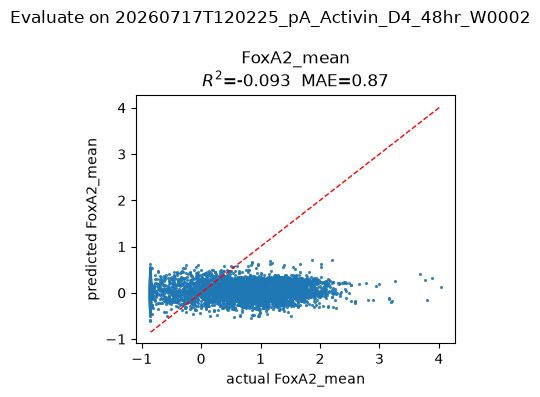

In [54]:
# Both units shown explicitly, same convention as the combined training cells above --
# R2 is NOT invariant under log1p_standard, so "scaled" and "original" can look very
# different for the same model. Default predict_df call = original units;
# y_scaler=None = scaled units.
pred_df, true_df = predict_df(model, eval_data, eval_mask, eval_cell_df.index, y_scaler=None)
r2_scaled = r2_table(true_df, pred_df)
display(r2_scaled)

fig_pred = plot_pred_vs_actual(true_df, pred_df, title=f'Evaluate on {EVAL_IMG_NAME}')
plt.show()

fig_pred.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_r2.png', dpi=300, bbox_inches='tight')

In [55]:
y_cols = list(pred_df.columns)
centroids_eval = eval_cell_df.loc[pred_df.index, ['centroid_x', 'centroid_y']]

spatial_data = centroids_eval.copy()
for col in y_cols:
    spatial_data[f'{col} (actual)'] = true_df[col].values
    spatial_data[f'{col} (predicted)'] = pred_df[col].values

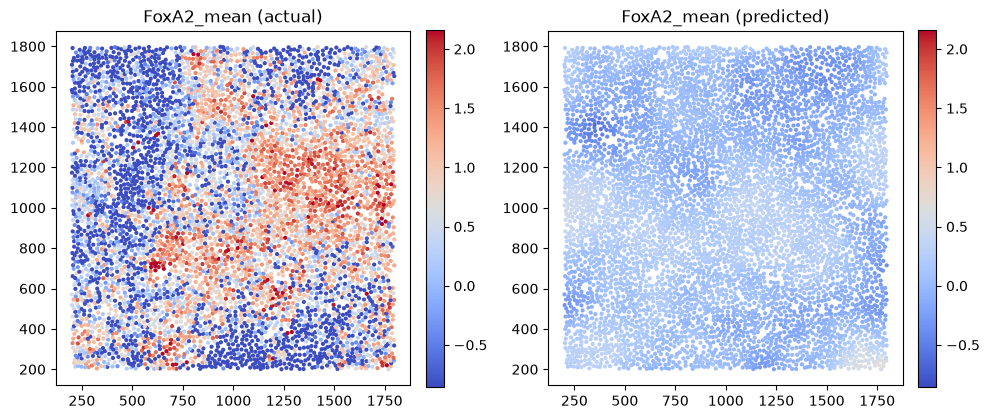

In [56]:
plot_cols = [x for x in spatial_data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
axs = np.atleast_1d(axs)

for i, col in enumerate(plot_cols):
    ax = axs[i]

    base_col = col.split(' (')[0]
    vmin, vmax = np.percentile(spatial_data[f'{base_col} (actual)'], [1, 99])
    sc = ax.scatter(
        spatial_data['centroid_x'], spatial_data['centroid_y'],
        c=spatial_data[col], cmap='coolwarm',
        s=4, vmin=vmin, vmax=vmax,
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

fig.savefig(f'{FIGURE_DIR}/{MODEL_TYPE}_{EVAL_IMG_NAME}_spatial.png', dpi=300)
plt.show()